In [2]:
import pandas as pd
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler
from gensim.models import Word2Vec

from joblib import load
import lightgbm as lgb
from joblib import dump
import itertools
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, accuracy_score, precision_score, recall_score, f1_score

import umap
import seaborn as sns

In [3]:
rice_df = pd.read_excel('rice_w2vec_3mer_64_dataset.xlsx')
rice_df = rice_df.drop(['tissue','chr','start','end','strand','start_anno', 'circID',	'gene', 'isoform', 'width', 'detection_score', 'stress_detection_score', 'end_anno', 'antisense', 'algorithm', 'exonSeq', 'predAA', 'miRNA','superCircRNARegion'], axis=1)

In [4]:
maize_df = pd.read_excel('maize_w2vec_3mer_64_dataset.xlsx')
maize_df = maize_df.drop(['tissue','chr','start','end','strand','start_anno', 'circID',	'gene', 'isoform', 'width', 'detection_score', 'stress_detection_score', 'end_anno', 'antisense', 'algorithm', 'exonSeq', 'predAA', 'miRNA','superCircRNARegion'], axis=1)

In [5]:
df = rice_df._append(maize_df, ignore_index = True)

In [ ]:
df_drought = df.query('stress == "-" or stress == "drought"').replace('-', 0).replace('drought', 1)
df_drought

In [ ]:
# Define X and y (target) variables
X = df_drought.drop(['stress', 'circName', 'seq'], axis=1)
y = df_drought['stress']

In [ ]:
ros = RandomUnderSampler(sampling_strategy=0.55)

X_res, y_res = ros.fit_resample(X, y)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.20, random_state=106)

In [ ]:
rus = RandomUnderSampler(sampling_strategy=1)

X_test, y_test = rus.fit_resample(X_test, y_test)
y_test.value_counts()

,count
stress,
0,2352
1,2352


In [ ]:
drought_model = load('rf_model_drought_3mer.joblib')

In [ ]:
w2v_model_maize = Word2Vec.load("word2vec_model_maize_3mer.bin")

In [ ]:
def get_kmers_for_dimension(model, dim_idx, top_n=10):
    words = list(model.wv.index_to_key)
    vectors = model.wv.vectors
    sorted_indices = np.argsort(vectors[:, dim_idx])[::-1]

    return [words[i] for i in sorted_indices[:top_n]]



### SHAP

In [ ]:
import shap

# Sample
X_test_sample = X_test.sample(n=min(1000, len(X_test)), random_state=106)

explainer = shap.TreeExplainer(drought_model)

shap_values = explainer.shap_values(X_test_sample, check_additivity=False)

In [ ]:
if isinstance(shap_values, list):
    shap_to_use = shap_values[1]
elif len(shap_values.shape) == 3:
    shap_to_use = shap_values[:, :, 1]
else:
    shap_to_use = shap_values

mean_shap = np.abs(shap_to_use).mean(axis=0)


df_impacto = pd.DataFrame({
    'Feature': X_test_sample.columns[:len(mean_shap)],
    'SHAP_Importance': mean_shap
})

top_features = df_impacto.nlargest(5, 'SHAP_Importance')
top_features

,Feature,SHAP_Importance
11,wc_3mer_12,0.033003
44,wc_3mer_45,0.028685
32,wc_3mer_33,0.023638
3,wc_3mer_4,0.014993
52,wc_3mer_53,0.014213


## Density Analysis

<>:55: SyntaxWarning: invalid escape sequence '\D'
<>:55: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipython-input-831870663.py:55: SyntaxWarning: invalid escape sequence '\D'
  plt.ylabel('Delta Density ($\Delta$)', fontsize=14)


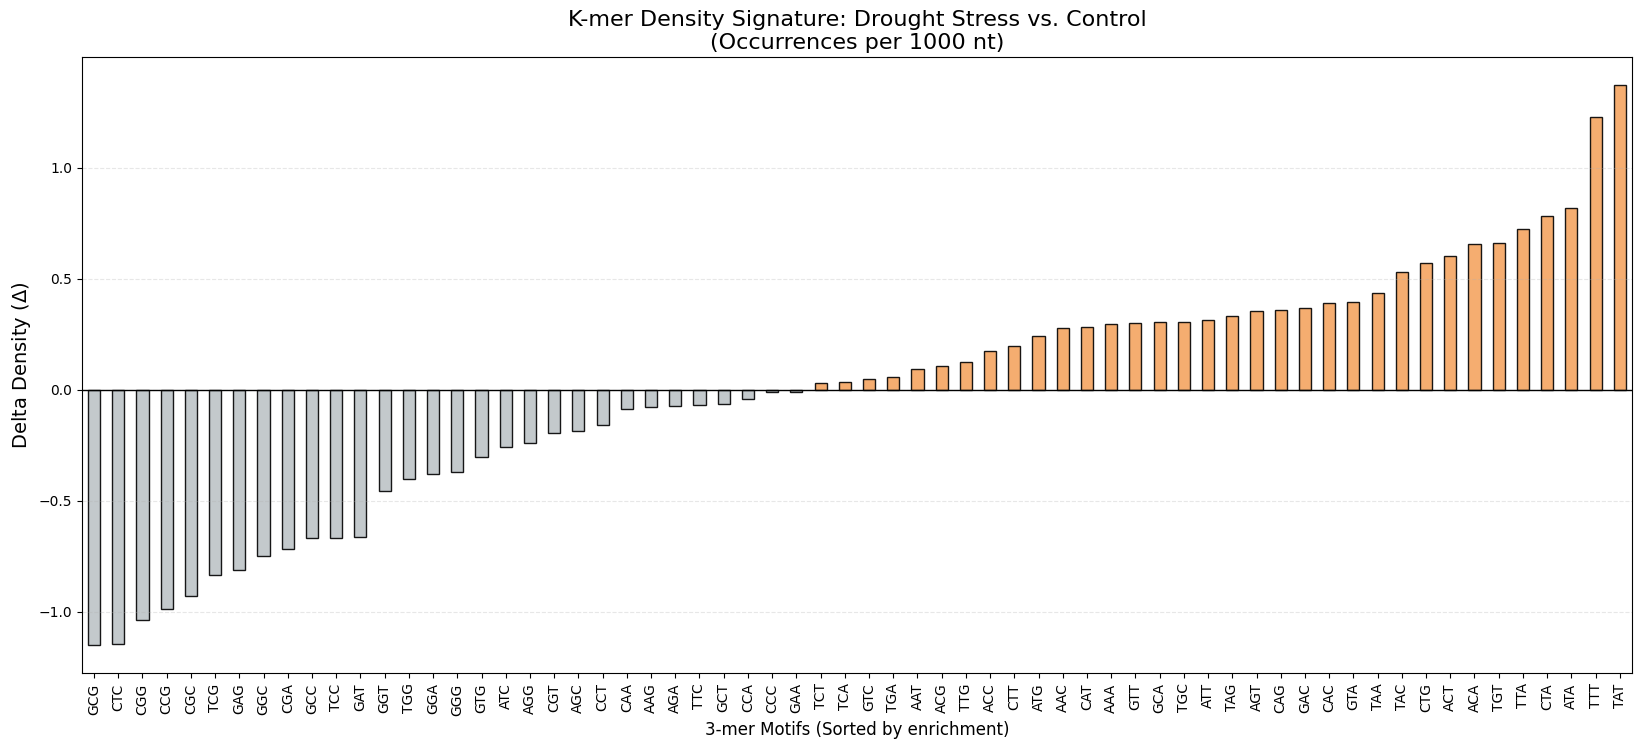


               TOP 10 DROUGHT-ENRICHED 3-mers               
condition    Drought    Control     Delta
TAT        19.415870  18.045366  1.370504
TTT        30.707960  29.479053  1.228906
ATA        15.555631  14.736740  0.818891
CTA        12.434695  11.651763  0.782931
TTA        16.277649  15.555691  0.721958
TGT        20.873846  20.212810  0.661036
ACA        16.586533  15.929928  0.656605
ACT        14.803171  14.201835  0.601336
CTG        19.172688  18.601466  0.571222
TAC        12.377334  11.845508  0.531826

               TOP 10 DROUGHT-DEPLETED 3-mers               
condition    Drought    Control     Delta
GCG         8.795149   9.946903 -1.151754
CTC        14.967143  16.111970 -1.144827
CGG         8.273842   9.309471 -1.035630
CCG         8.714319   9.700425 -0.986105
CGC         9.233390  10.163067 -0.929677
TCG         8.791444   9.627091 -0.835647
GAG        16.122024  16.935885 -0.813861
GGC        13.070584  13.820757 -0.750173
CGA         8.242218   8.960815 -0.7

In [ ]:
from itertools import product
from collections import Counter

# Generate all possible 3-mer combinations (64 total)
all_3mers = [''.join(p) for p in product('ACGT', repeat=3)]

def calculate_kmer_density(seq):
    """
    Calculates the density of each 3-mer normalized per 1000 nucleotides.
    """
    seq = str(seq).upper()
    seq_len = len(seq)

    if seq_len < 3:
        return pd.Series([0.0]*64, index=all_3mers)

    # Extract all overlapping 3-mers
    kmers_in_seq = [seq[i:i+3] for i in range(seq_len - 2)]
    counts = Counter(kmers_in_seq)

    # Formula: (Count / Sequence Length) * 1000
    densities = [(counts[kmer] / seq_len) * 1000 for kmer in all_3mers]
    return pd.Series(densities, index=all_3mers)

# 1. Filter dataset for Control (-) and Drought stress conditions
# Ensure your rice_df has the 'drought' label in the stress column
df_analysis = df.query('stress == "-" or stress == "drought"').copy()
df_analysis['condition'] = df_analysis['stress'].replace({'-': 'Control', 'drought': 'Drought'})

# 2. Apply density calculation
kmer_densities = df_analysis['seq'].apply(calculate_kmer_density)

# 3. Combine labels with density data
df_final = pd.concat([df_analysis[['condition']], kmer_densities], axis=1)

# 4. Calculate Mean Density per group
summary = df_final.groupby('condition')[all_3mers].mean()
diff_summary = summary.T

# 5. Compute Delta (Difference) and Relative Variation
# Using Drought as the treatment group
diff_summary['Delta'] = diff_summary['Drought'] - diff_summary['Control']
diff_summary['Rel_Change_Pct'] = (diff_summary['Delta'] / diff_summary['Control']) * 100

# --- Visualization: Delta Density Bar Chart ---
plt.figure(figsize=(20, 8))
ordered_diff = diff_summary.sort_values(by='Delta')

# Adjusted Color mapping for Drought:
colors = ['#f4a460' if x > 0 else '#bdc3c7' for x in ordered_diff['Delta']]

ordered_diff['Delta'].plot(kind='bar', color=colors, edgecolor='black', alpha=0.9)

plt.title('K-mer Density Signature: Drought Stress vs. Control\n(Occurrences per 1000 nt)', fontsize=16)
plt.ylabel('Delta Density ($\Delta$)', fontsize=14)
plt.xlabel('3-mer Motifs (Sorted by enrichment)', fontsize=12)
plt.axhline(0, color='black', linewidth=1)
plt.grid(axis='y', linestyle='--', alpha=0.3)

# 6. Save as high-resolution TIFF
plt.savefig('kmer_density_signature_drought.tiff',
            dpi=300,
            format='tiff',
            bbox_inches='tight',
            pil_kwargs={'compression': 'tiff_lzw'})

plt.show()

# --- Print Top 10 Enriched and Depleted Motifs ---
print("\n" + "="*60)
print(f"{'TOP 10 DROUGHT-ENRICHED 3-mers':^60}")
print("="*60)
print(ordered_diff[['Drought', 'Control', 'Delta']].tail(10).iloc[::-1])

print("\n" + "="*60)
print(f"{'TOP 10 DROUGHT-DEPLETED 3-mers':^60}")
print("="*60)
print(ordered_diff[['Drought', 'Control', 'Delta']].head(10))

<>:45: SyntaxWarning: invalid escape sequence '\D'
<>:45: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipython-input-3741082845.py:45: SyntaxWarning: invalid escape sequence '\D'
  plt.ylabel('Delta Density ($\Delta$)', fontsize=14)


Processing Rice...
Success: kmer_density_drought_rice.tiff saved.


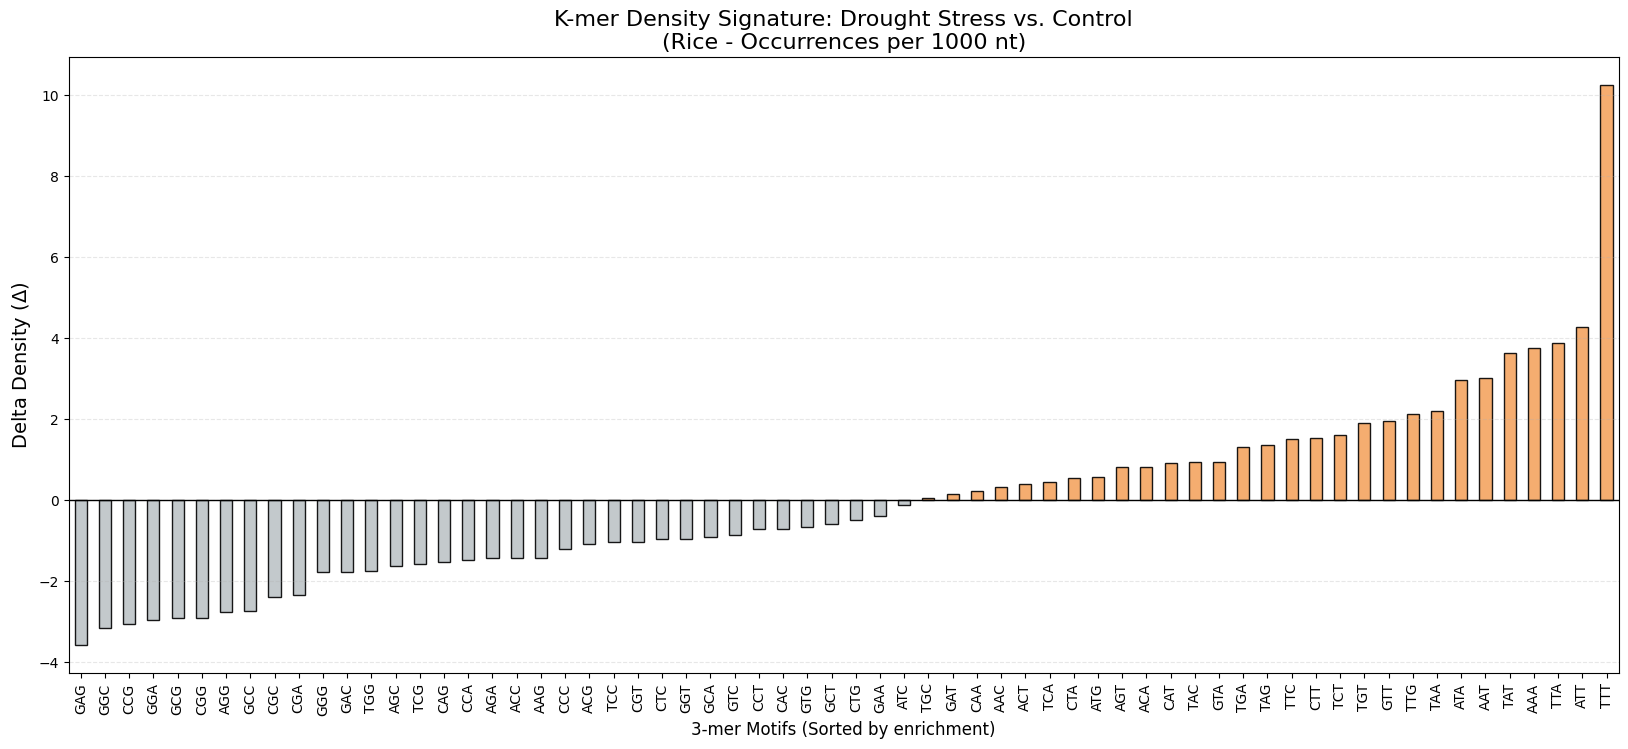

Processing Maize...
Success: kmer_density_drought_maize.tiff saved.


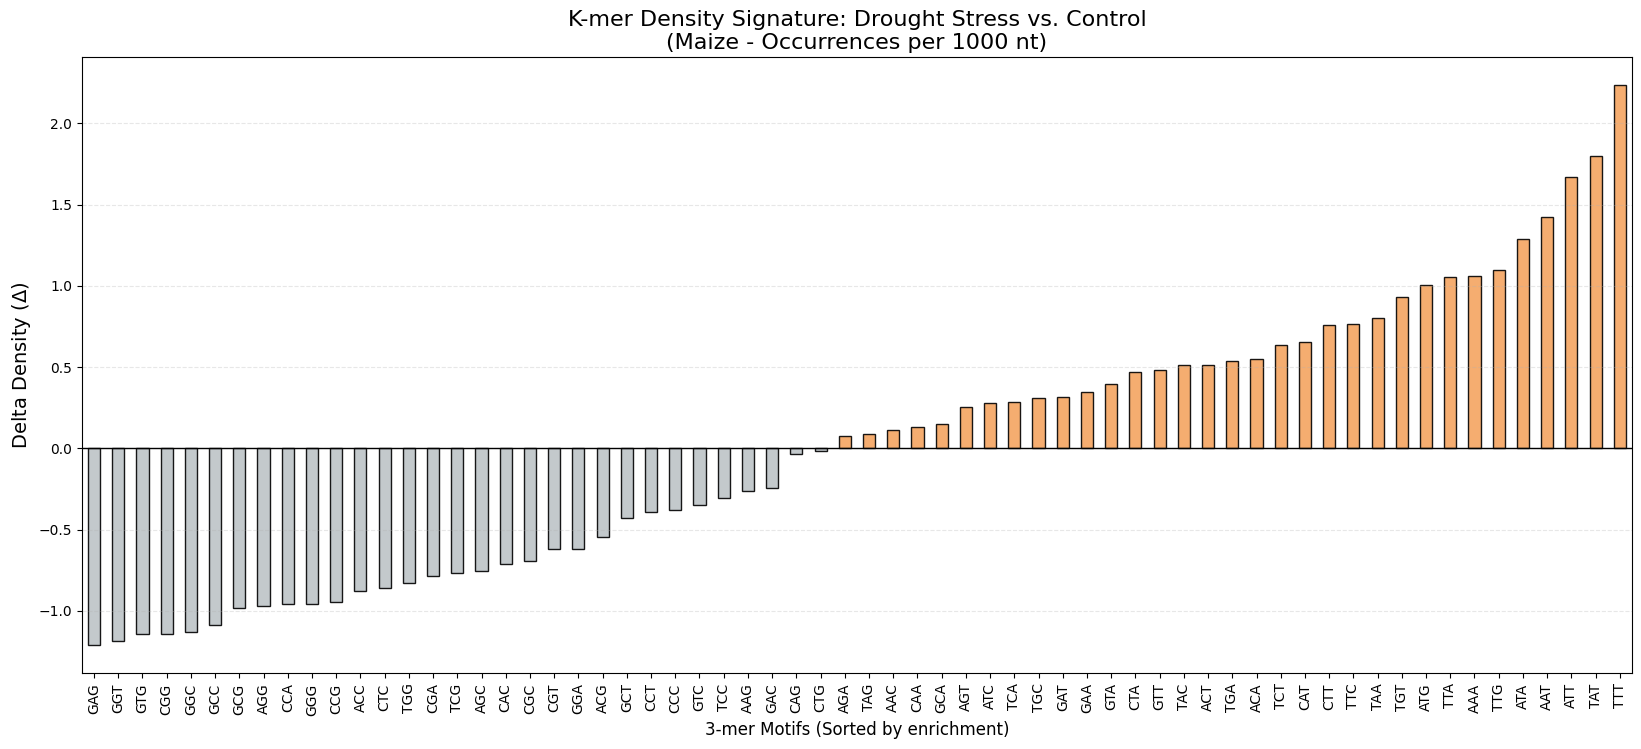

In [ ]:
# 1. Configuração Global
all_3mers = [''.join(p) for p in product('ACGT', repeat=3)]

def calculate_kmer_density(seq):
    seq = str(seq).upper()
    seq_len = len(seq)
    if seq_len < 3:
        return pd.Series([0.0]*64, index=all_3mers)

    kmers_in_seq = [seq[i:i+3] for i in range(seq_len - 2)]
    counts = Counter(kmers_in_seq)
    densities = [(counts[kmer] / seq_len) * 1000 for kmer in all_3mers]
    return pd.Series(densities, index=all_3mers)

def generate_drought_signature_plot(df_species, species_name):
    """
    Filters data for a specific species, calculates density,
    and saves the Delta Density plot.
    """
    print(f"Processing {species_name}...")

    # Filtering and condition labeling
    df_analysis = df_species.query('stress == "-" or stress == "drought"').copy()
    df_analysis['condition'] = df_analysis['stress'].replace({'-': 'Control', 'drought': 'Drought'})

    # K-mer density calculation
    kmer_densities = df_analysis['seq'].apply(calculate_kmer_density)
    df_final = pd.concat([df_analysis[['condition']], kmer_densities], axis=1)

    # Statistics: Mean and Delta
    summary = df_final.groupby('condition')[all_3mers].mean()
    diff_summary = summary.T
    diff_summary['Delta'] = diff_summary['Drought'] - diff_summary['Control']

    # Sorting for visualization
    ordered_diff = diff_summary.sort_values(by='Delta')

    # Visualization
    plt.figure(figsize=(20, 8))
    colors = ['#f4a460' if x > 0 else '#bdc3c7' for x in ordered_diff['Delta']]

    ordered_diff['Delta'].plot(kind='bar', color=colors, edgecolor='black', alpha=0.9)

    plt.title(f'K-mer Density Signature: Drought Stress vs. Control\n({species_name} - Occurrences per 1000 nt)', fontsize=16)
    plt.ylabel('Delta Density ($\Delta$)', fontsize=14)
    plt.xlabel('3-mer Motifs (Sorted by enrichment)', fontsize=12)
    plt.axhline(0, color='black', linewidth=1)
    plt.grid(axis='y', linestyle='--', alpha=0.3)

    # High-resolution export
    filename = f'kmer_density_drought_{species_name.lower()}.tiff'
    plt.savefig(filename,
                dpi=300,
                format='tiff',
                bbox_inches='tight',
                pil_kwargs={'compression': 'tiff_lzw'})

    print(f"Success: {filename} saved.")
    plt.show()

# --- Execution ---

# Generate plot for Rice
generate_drought_signature_plot(rice_df, "Rice")

# Generate plot for Maize
generate_drought_signature_plot(maize_df, "Maize")

The data reveals a consistent GC-to-AT shift across both species, but with significant differences in magnitude:

Rice (High Magnitude): Rice exhibits a much more aggressive response. The top enriched motif (TTT) reached a Delta ($\Delta$) of ~10.2, meaning that under drought, rice circRNAs accumulate 10 extra TTT motifs for every 1000 nt compared to the control.

Maize (Lower Magnitude): In contrast, Maize shows a more "dampened" k-mer reorganization. The same TTT motif in maize has a Delta of ~2.2. This suggests that while the direction of the change is the same, the circRNA population in rice undergoes a more radical sequence reconfiguration.

K-mer Density Normalization:

To account for the varying lengths of circRNA transcripts, we calculated the Normalized K-mer Density ($D_i$). This transformation ensures that the results represent the motif concentration rather than absolute counts, allowing for a fair comparison across the entire library. The density for a specific 3-mer ($i$) in a sequence ($j$) is defined as:

$$D_{i,j} = \left( \frac{C_{i,j}}{L_j} \right) \times 1000$$$C_{i,j}$: Absolute count of 3-mer $i$ in sequence $j$.$L_j$: Length of sequence $j$ in nucleotides.$1000$: Scaling factor to express density as occurrences per kilobase (kb).Comparative Group Analysis (Delta Density)To identify shifts in the genomic signature between conditions, we calculated the Delta Density ($\Delta D_i$), which represents the arithmetic difference between the mean densities of the Stress and Control groups:$$\Delta D_i = \bar{D}_{i,Stress} - \bar{D}_{i,Control}$$Where $\bar{D}_i$ is the average density of motif $i$ across all transcripts in the respective group:$$\bar{D}_i = \frac{1}{n} \sum_{j=1}^{n} D_{i,j}$$A positive $\Delta D_i$ indicates that the motif is enriched under stress, while a negative value signifies depletion (enrichment in the control condition).

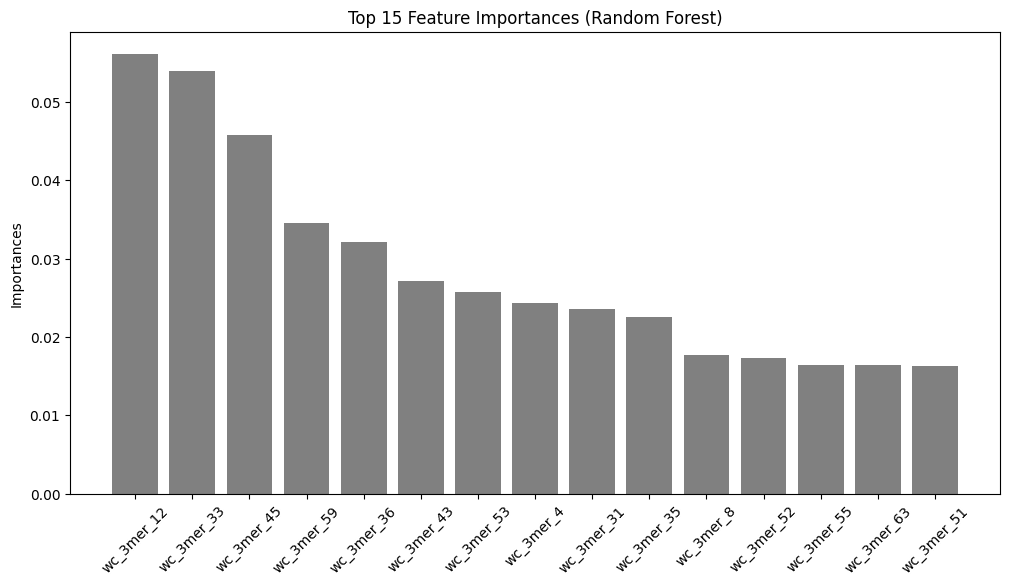

       Feature  Importance
11  wc_3mer_12    0.056113
32  wc_3mer_33    0.053929
44  wc_3mer_45    0.045782
58  wc_3mer_59    0.034557
35  wc_3mer_36    0.032092
42  wc_3mer_43    0.027096
52  wc_3mer_53    0.025727
3    wc_3mer_4    0.024298
30  wc_3mer_31    0.023543
34  wc_3mer_35    0.022575
7    wc_3mer_8    0.017728
51  wc_3mer_52    0.017354
54  wc_3mer_55    0.016484
62  wc_3mer_63    0.016379
50  wc_3mer_51    0.016282


In [ ]:
importances = drought_model.feature_importances_
feature_names = [f'wc_3mer_{i+1}' for i in range(len(importances))]

df_importances = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 6))
plt.bar(df_importances['Feature'].head(15), df_importances['Importance'].head(15), color='grey')
plt.xticks(rotation=45)
plt.title('Top 15 Feature Importances (Random Forest)')
plt.ylabel('Importances')
plt.show()

print(df_importances.head(15))

In [ ]:
# 1. Configuration
target_dimensions = [12, 33, 45, 59]
# Matches your Word2Vec prefix (e.g., 'wc_3mer_21')
prefix = 'wc_3mer'

# 2. Access Word2Vec Data
vectors = w2v_model_maize.wv.vectors
kmers = w2v_model_maize.wv.index_to_key

# Dictionary to store results for each dimension
dimension_results = {}

print(f"--- QUANTITATIVE ANALYSIS OF TOP SHAP DIMENSIONS ---")

for dim in target_dimensions:
    python_idx = dim - 1

    # Extract weights and calculate relative contribution percentage
    vector_weights = vectors[:, python_idx]
    squared_importance = vector_weights**2
    contribution_pct = (squared_importance / squared_importance.sum()) * 100

    # Create DataFrame for the current dimension
    df_dim = pd.DataFrame({
        'K-mer': kmers,
        'Weight': vector_weights,
        'Contribution_Pct': contribution_pct
    })

    # Sort by absolute strength (Contribution %)
    top_10 = df_dim.sort_values(by='Contribution_Pct', ascending=False).head(10)
    dimension_results[dim] = top_10

    # Formatted Output
    print(f"\n>> {prefix}_{dim} (Actual Index: {python_idx})")
    print(top_10.to_string(index=False))
    print("-" * 50)

--- QUANTITATIVE ANALYSIS OF TOP SHAP DIMENSIONS ---

>> wc_3mer_12 (Actual Index: 11)
K-mer    Weight  Contribution_Pct
  CGT  2.164095          9.762992
  GGT  1.923066          7.709364
  AAC  1.815916          6.874195
  CTA -1.626487          5.514825
  TGG -1.569339          5.134095
  AGG -1.482429          4.581188
  TAT  1.480862          4.571511
  ATA -1.446020          4.358919
  AGT  1.411608          4.153926
  GTA -1.402703          4.101683
--------------------------------------------------

>> wc_3mer_33 (Actual Index: 32)
K-mer    Weight  Contribution_Pct
  GTT -2.274139         11.795214
  GTC -1.938205          8.567838
  GCT  1.786828          7.281777
  CGT  1.690800          6.520133
  ACT  1.620255          5.987406
  GTA -1.584261          5.724339
  GGA -1.551218          5.488046
  AGC -1.495881          5.103473
  AGA -1.308376          3.904247
  CGG  1.224667          3.420644
--------------------------------------------------

>> wc_3mer_45 (Actual Index:

In [ ]:
df_analysis_drought = df.query('stress == "drought"')

In [ ]:
df_analysis_control = df.query('stress == "-"')

In [ ]:
# 1. Apply the density calculation to the control group sequences
control_densities = df_analysis_control['seq'].apply(calculate_kmer_density)

# 2. Calculate the MEAN density for the entire group
# This represents the average occurrence of each k-mer per 1000nt across all transcripts
mean_density_control = control_densities.mean()

# 3. Convert to DataFrame and sort by density
df_final_ctrl = mean_density_control.to_frame(name='Mean_Density_Per_1000nt')
df_final_ctrl.index.name = 'K-mer'
df_final_ctrl = df_final_ctrl.sort_values(by='Mean_Density_Per_1000nt', ascending=False)

# 4. Print results using standardized English headers
print("="*50)
print(f"{'TOP 10 HIGHEST DENSITY (CONTROL GROUP)':^50}")
print("="*50)
print(df_final_ctrl.head(10))

print("\n" + "="*50)
print(f"{'TOP 10 LOWEST DENSITY (CONTROL GROUP)':^50}")
print("="*50)
print(df_final_ctrl.tail(10))

      TOP 10 HIGHEST DENSITY (CONTROL GROUP)      
       Mean_Density_Per_1000nt
K-mer                         
TTT                  29.479053
TTG                  23.636909
ATT                  21.469962
AAA                  21.258216
ATG                  20.891424
TGA                  20.706900
TTC                  20.394310
TGT                  20.212810
TCT                  19.992669
CTT                  19.855694

      TOP 10 LOWEST DENSITY (CONTROL GROUP)       
       Mean_Density_Per_1000nt
K-mer                         
CCC                  10.204019
TAG                  10.187427
CGC                  10.163067
GCG                   9.946903
CCG                   9.700425
TCG                   9.627091
CGG                   9.309471
CGA                   8.960815
CGT                   7.780631
ACG                   6.985583


In [ ]:
# 1. Apply the density calculation to the drought stress group sequences
# This captures the motif profile during desiccation/water deficit
drought_densities = df_analysis_drought['seq'].apply(calculate_kmer_density)

# 2. Calculate the MEAN density for the entire drought stress group
# This provides the average genomic signature under drought conditions
mean_density_drought = drought_densities.mean()

# 3. Convert to DataFrame and sort by mean density
df_final_drought = mean_density_drought.to_frame(name='Mean_Density_Per_1000nt')
df_final_drought.index.name = 'K-mer'
df_final_drought = df_final_drought.sort_values(by='Mean_Density_Per_1000nt', ascending=False)

# 4. Print results using standardized English headers for Drought
print("="*60)
print(f"{'TOP 10 HIGHEST DENSITY (DROUGHT STRESS GROUP)':^60}")
print("="*60)
print(df_final_drought.head(10))

print("\n" + "="*60)
print(f"{'TOP 10 LOWEST DENSITY (DROUGHT STRESS GROUP)':^60}")
print("="*60)
print(df_final_drought.tail(10))

       TOP 10 HIGHEST DENSITY (DROUGHT STRESS GROUP)        
       Mean_Density_Per_1000nt
K-mer                         
TTT                  30.707960
TTG                  23.763451
ATT                  21.785757
AAA                  21.555657
ATG                  21.134264
TGT                  20.873846
TGA                  20.763031
TTC                  20.326994
CTT                  20.051471
TCT                  20.021310

        TOP 10 LOWEST DENSITY (DROUGHT STRESS GROUP)        
       Mean_Density_Per_1000nt
K-mer                         
GGG                  10.428244
CCC                  10.191883
CGC                   9.233390
GCG                   8.795149
TCG                   8.791444
CCG                   8.714319
CGG                   8.273842
CGA                   8.242218
CGT                   7.585069
ACG                   7.090408


In [ ]:
# 1. Generate mean densities for both conditions
mean_control = df_analysis_control['seq'].apply(calculate_kmer_density).mean()
mean_drought = df_analysis_drought['seq'].apply(calculate_kmer_density).mean()

# 2. Construct df_comp (This is the missing variable)
df_comp = pd.DataFrame({
    'Control_Avg': mean_control,
    'Drought_Avg': mean_drought
})

# 3. Calculate metrics
df_comp['Delta'] = df_comp['Drought_Avg'] - df_comp['Control_Avg']
df_comp['Fold_Change'] = (df_comp['Drought_Avg'] + 0.01) / (df_comp['Control_Avg'] + 0.01)
df_comp['Log2FC'] = np.log2(df_comp['Fold_Change'])

print("df_comp successfully defined.")

df_comp successfully defined.


In [ ]:
print(f"Max Fold Change: {df_comp['Fold_Change'].max():.4f}")
print(f"Min Fold Change: {df_comp['Fold_Change'].min():.4f}")
print(f"Max Density: {df_comp['Drought_Avg'].max():.4f}")

Max Fold Change: 1.0759
Min Fold Change: 0.8843
Max Density: 30.7080


In [ ]:
# --- MICRO-SHIFT ANALYSIS (5% Threshold) ---
# Since the max variation is ~7.5%, we use a 5% cut-off to see the trends

# 1. Drought-Enriched (Top 5% increase)
enriched_micro = df_comp[
    (df_comp['Fold_Change'] > 1.05) & (df_comp['Drought_Avg'] > 1.0)
].sort_values(by='Log2FC', ascending=False)

# 2. Drought-Depleted (Top 5% decrease)
# 1 / 1.05 is approx 0.95
depleted_micro = df_comp[
    (df_comp['Fold_Change'] < 0.95) & (df_comp['Control_Avg'] > 1.0)
].sort_values(by='Log2FC', ascending=True)

# --- RESULTS REPORTING ---
print("\n" + "="*80)
print(f"{'SENSITIVE ANALYSIS: DROUGHT MICRO-SHIFTS (> 5% CHANGE)':^80}")
print("="*80)
print("TOP ENRICHED (DROUGHT):")
print(enriched_micro.head(10))

print("\nTOP DEPLETED (CONTROL):")
print(depleted_micro.head(10))


             SENSITIVE ANALYSIS: DROUGHT MICRO-SHIFTS (> 5% CHANGE)             
TOP ENRICHED (DROUGHT):
     Control_Avg  Drought_Avg     Delta  Fold_Change    Log2FC
TAT    18.045366    19.415870  1.370504     1.075906  0.105552
CTA    11.651763    12.434695  0.782931     1.067137  0.093745
ATA    14.736740    15.555631  0.818891     1.055530  0.077968

TOP DEPLETED (CONTROL):
     Control_Avg  Drought_Avg     Delta  Fold_Change    Log2FC
GCG     9.946903     8.795149 -1.151754     0.884326 -0.177350
CGG     9.309471     8.273842 -1.035630     0.888875 -0.169948
CCG     9.700425     8.714319 -0.986105     0.898449 -0.154492
CGC    10.163067     9.233390 -0.929677     0.908614 -0.138261
TCG     9.627091     8.791444 -0.835647     0.913288 -0.130858
CGA     8.960815     8.242218 -0.718597     0.919896 -0.120457
CTC    16.111970    14.967143 -1.144827     0.928990 -0.106266
GGC    13.820757    13.070584 -0.750173     0.945761 -0.080453
GCC    13.289649    12.622929 -0.666720     0.9498

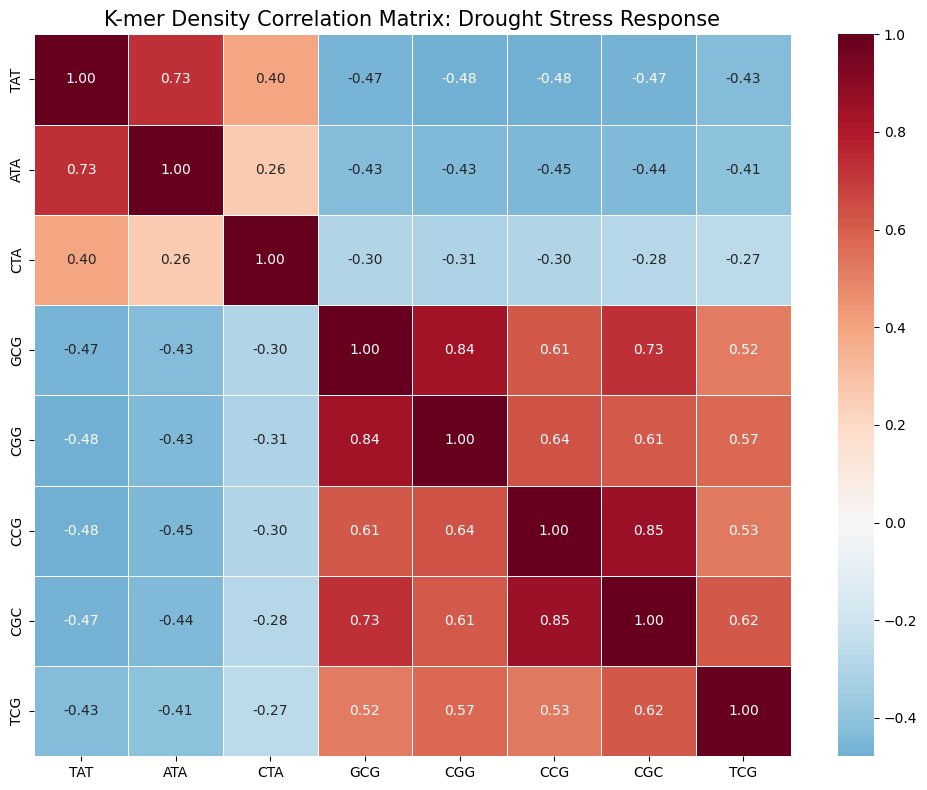

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

selected_kmers = ['TAT', 'ATA', 'CTA', 'GCG', 'CGG', 'CCG', 'CGC', 'TCG']

correlation_data = kmer_densities[selected_kmers]

# 3. Calcular a Matriz de Correlação de Pearson
corr_matrix = correlation_data.corr()

# 4. Configurar a visualização
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix,
            annot=True,
            cmap='RdBu_r', # Vermelho (positivo), Azul (negativo)
            center=0,
            fmt='.2f',
            linewidths=0.5)

plt.title('K-mer Density Correlation Matrix: Drought Stress Response', fontsize=15)

# 5. Exportação em Alta Resolução (TIFF)
plt.tight_layout()

plt.show()

/tmp/ipython-input-264424922.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Log2FC', y=top_plot.index, data=top_plot, palette=colors)


Success: drought_differential_density_plot.tiff exported.


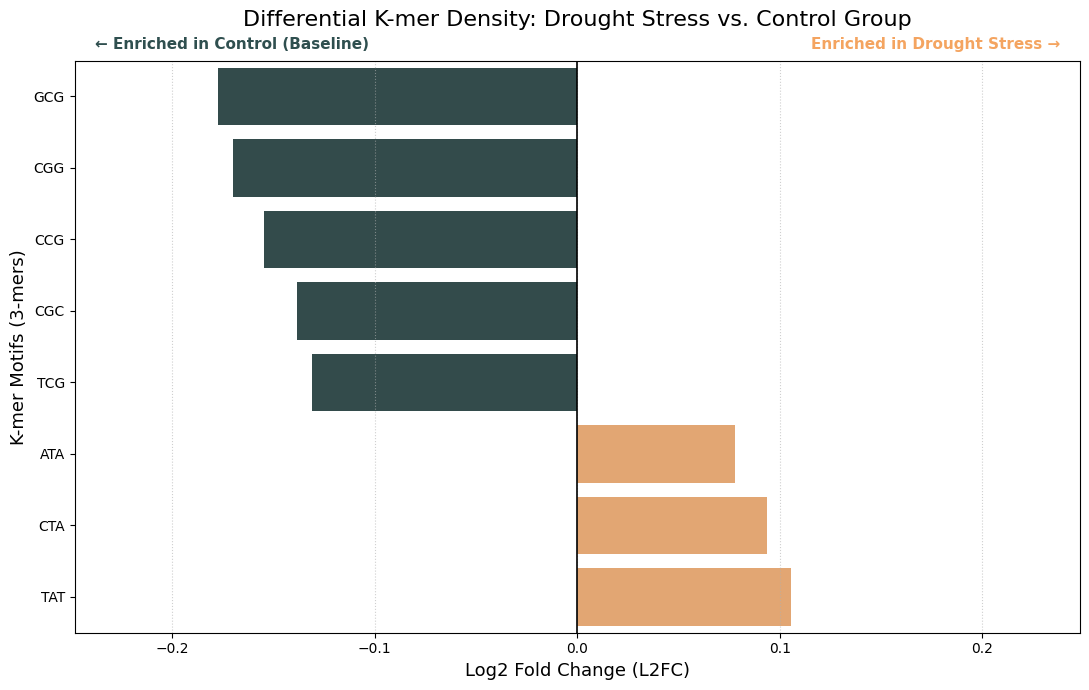

In [ ]:
# Combining the Top 5 Drought-Enriched and Top 5 Drought-Depleted markers
# These DataFrames were generated in the Micro-Shift analysis step
top_plot = pd.concat([enriched_micro.head(5), depleted_micro.head(5)])
top_plot = top_plot.sort_values(by='Log2FC')

plt.figure(figsize=(11, 7))

# Color palette for Drought:
# SandyBrown (#f4a460) for positive values (Drought-enriched)
# DarkSlateGray (#2f4f4f) for negative values (Drought-depleted/Control-enriched)
colors = ['#2f4f4f' if x < 0 else '#f4a460' for x in top_plot['Log2FC']]

# 2. Create the horizontal bar plot
ax = sns.barplot(x='Log2FC', y=top_plot.index, data=top_plot, palette=colors)

# 3. Dynamic X-axis limits
# Provides 40% extra space to ensure annotations do not overlap with bars
x_limit = max(abs(top_plot['Log2FC'].min()), abs(top_plot['Log2FC'].max())) * 1.4
plt.xlim(-x_limit, x_limit)

# 4. Titles and Labels (Scientific English)
plt.title('Differential K-mer Density: Drought Stress vs. Control Group', fontsize=16, pad=25)
plt.xlabel('Log2 Fold Change (L2FC)', fontsize=13)
plt.ylabel('K-mer Motifs (3-mers)', fontsize=13)

# Add a central reference line for zero change
plt.axvline(0, color='black', linewidth=1.2, linestyle='-')

# 5. Strategic Label Placement (Upper corners)
# Using axes fraction to keep text in fixed positions relative to the frame
plt.text(0.98, 1.02, 'Enriched in Drought Stress →',
         transform=ax.transAxes, color='#f4a460', fontweight='bold', ha='right', fontsize=11)

plt.text(0.02, 1.02, '← Enriched in Control (Baseline)',
         transform=ax.transAxes, color='#2f4f4f', fontweight='bold', ha='left', fontsize=11)

# Fine-tuning grid aesthetics for better readability
plt.grid(axis='x', linestyle=':', alpha=0.6)
plt.tight_layout()

# 6. High-Resolution TIFF Export
# Using 300 DPI and LZW compression for thesis-ready publication quality
plt.savefig('drought_differential_density_plot.tiff',
            dpi=300,
            format='tiff',
            bbox_inches='tight',
            pil_kwargs={'compression': 'tiff_lzw'})

print("Success: drought_differential_density_plot.tiff exported.")
plt.show()

The Delta ($\Delta$) Argument (Absolute Abundance)

The Log2FC Argument (Relative Sensitivity)

In [45]:
# zma-circ9294-Zm00001d029872; Oxysterol-binding protein-related protein 2A ; Silencing of GhORP_A02 enhances drought tolerance in Gossypium hirsutum

target_sequence = "TCAGTCATCATCCTATGGTCATGGCATGTCACTGTGAGGGGAAAGGTTGGAAATTTTGGGGAGACAGCAATCTGAAGAGCAAATTCTGGGGACAATCCATTCAATTGGATCCTAATGGTGTGCTAACTTTAGAGTTTGATGATGGAGAAATTTTCCAATGGAGCAAG"

# 1. Calculate density using the standardized function
density_results = calculate_kmer_density(target_sequence)

# 2. Convert to DataFrame and set column names
df_sorted = density_results.to_frame(name='Density_Per_1000nt')
df_sorted.index.name = 'K-mer'

# 3. Sort by density (Descending order)
df_final = df_sorted.sort_values(by='Density_Per_1000nt', ascending=False)

# 4. Print both extremes (Top and Bottom 10)
print("="*50)
print(f"{'TOP 10 HIGHEST DENSITY':^50}")
print("="*50)
print(df_final.head(10))

print("\n" + "="*50)
print(f"{'TOP 10 LOWEST DENSITY':^50}")
print("="*50)
print(df_final.tail(10))

              TOP 10 HIGHEST DENSITY              
       Density_Per_1000nt
K-mer                    
TGG             53.892216
AAT             47.904192
GGA             41.916168
ATG             41.916168
TTT             35.928144
CAA             35.928144
TCA             35.928144
GGG             35.928144
GAG             35.928144
CAT             29.940120

              TOP 10 LOWEST DENSITY               
       Density_Per_1000nt
K-mer                    
ACG                   0.0
TAC                   0.0
CGT                   0.0
GTA                   0.0
CGA                   0.0
CGC                   0.0
GCG                   0.0
GCC                   0.0
CGG                   0.0
CCG                   0.0


In [55]:
# osa-circ12759-OS03T0845500 ; acyl-activating enzyme 16
target_sequence = "CTCAATTCAGAGACAGATATCTTCCAGTTCAACTGCTCGGAAATTTGTTGCTCTTGCACTTATTAAGATAAGTTTGCTATATATGGAGGCAAAGAGGATATACGA"

# 1. Calculate density using the standardized function
density_results = calculate_kmer_density(target_sequence)

# 2. Convert to DataFrame and set column names
df_sorted = density_results.to_frame(name='Density_Per_1000nt')
df_sorted.index.name = 'K-mer'

# 3. Sort by density (Descending order)
df_final = df_sorted.sort_values(by='Density_Per_1000nt', ascending=False)

# 4. Print both extremes (Top and Bottom 10)
print("="*50)
print(f"{'TOP 10 HIGHEST DENSITY':^50}")
print("="*50)
print(df_final.head(10))

print("\n" + "="*50)
print(f"{'TOP 10 LOWEST DENSITY':^50}")
print("="*50)
print(df_final.tail(10))

              TOP 10 HIGHEST DENSITY              
       Density_Per_1000nt
K-mer                    
ATA             57.142857
TAT             57.142857
AGA             47.619048
TTG             38.095238
TGC             38.095238
CTT             28.571429
GCT             28.571429
CAA             28.571429
ATT             28.571429
GGA             28.571429

              TOP 10 LOWEST DENSITY               
       Density_Per_1000nt
K-mer                    
CCC                   0.0
TAG                   0.0
CAT                   0.0
GCC                   0.0
GTG                   0.0
GTC                   0.0
CGC                   0.0
GGT                   0.0
GGG                   0.0
GTA                   0.0


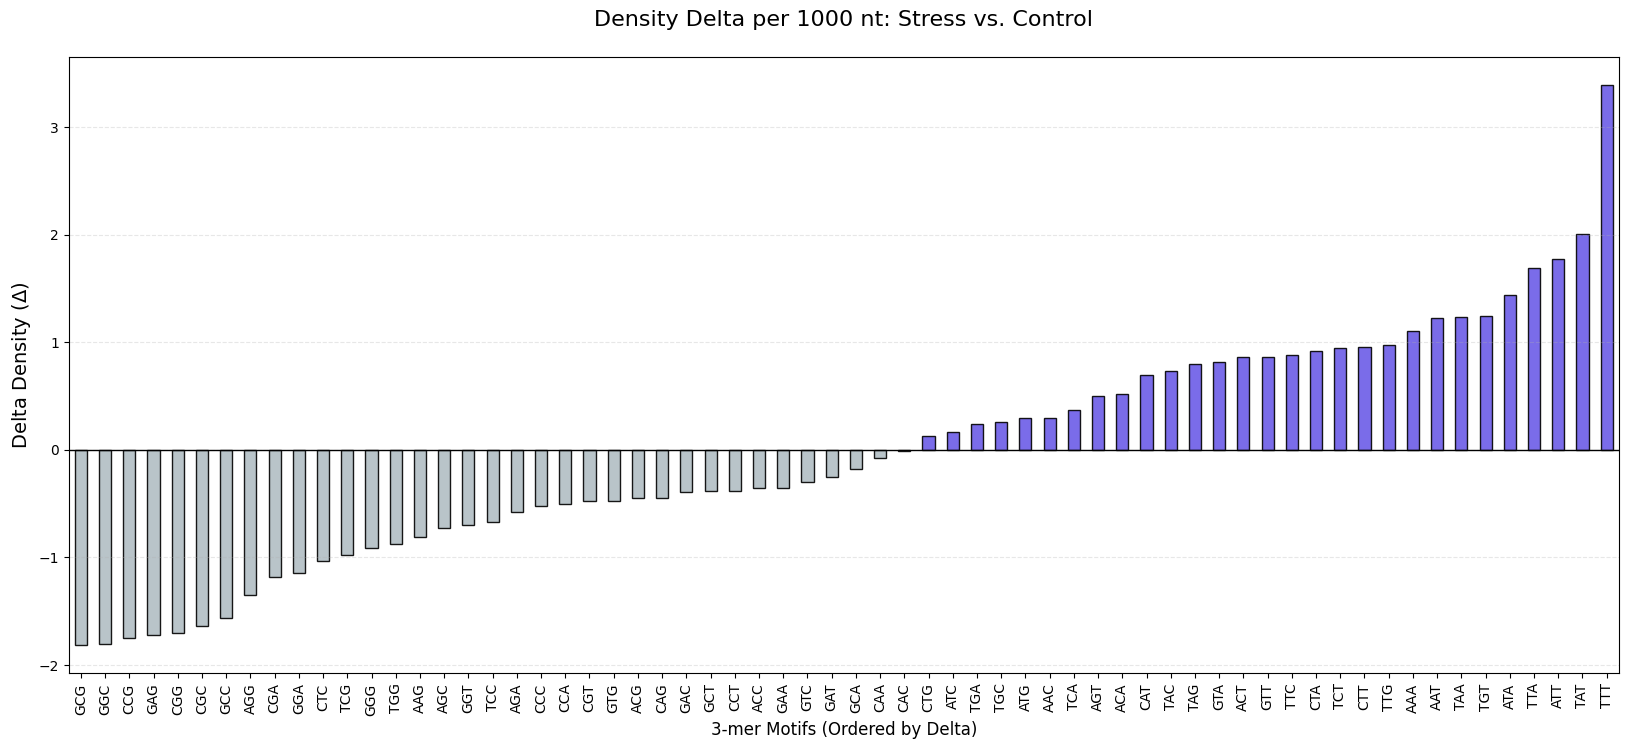

Total sequences analyzed: 88750
stress
-          70996
drought    12030
cold        5724
Name: count, dtype: int64


In [8]:
from itertools import product
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt

# 1. Standard setup for 3-mers
all_3mers = [''.join(p) for p in product('ACGT', repeat=3)]

def calculate_kmer_density(seq):
    seq = str(seq).upper()
    seq_len = len(seq)
    if seq_len < 3:
        return pd.Series([0.0]*64, index=all_3mers)
    kmers_in_seq = [seq[i:i+3] for i in range(seq_len - 2)]
    counts = Counter(kmers_in_seq)
    densities = [(counts[kmer] / seq_len) * 1000 for kmer in all_3mers]
    return pd.Series(densities, index=all_3mers)

# 2. Targeted Filtering
# We select ONLY Control (-), Cold, and Drought
target_conditions = ['-', 'cold', 'drought']
df_analysis = df[df['stress'].isin(target_conditions)].copy()

# 3. Define the Unified Condition
# Labels everything that is not '-' as 'Stress' (within our filtered subset)
df_analysis['condition'] = df_analysis['stress'].apply(lambda x: 'Control' if x == '-' else 'Stress')

# 4. Apply density calculation to the filtered data
kmer_densities = df_analysis['seq'].apply(calculate_kmer_density)

# 5. Combine and aggregate
df_final = pd.concat([df_analysis[['condition']], kmer_densities], axis=1)
summary = df_final.groupby('condition')[all_3mers].mean()
diff_summary = summary.T

# 6. Calculate Metrics
diff_summary['Delta'] = diff_summary['Stress'] - diff_summary['Control']

# --- Visualization ---
plt.figure(figsize=(20, 8))
ordered_diff = diff_summary.sort_values(by='Delta')

# Using a distinct palette for this combined analysis
# Stress-enriched: Purple (#6c5ce7) | Stress-depleted: Silver (#b2bec3)
colors = ['#6c5ce7' if x > 0 else '#b2bec3' for x in ordered_diff['Delta']]

ordered_diff['Delta'].plot(kind='bar', color=colors, edgecolor='black', alpha=0.9)

plt.title('Density Delta per 1000 nt: Stress vs. Control\n', fontsize=16)
plt.ylabel('Delta Density ($\Delta$)', fontsize=14)
plt.xlabel('3-mer Motifs (Ordered by Delta)', fontsize=12)
plt.axhline(0, color='black', linewidth=1)
plt.grid(axis='y', linestyle='--', alpha=0.3)

# 7. High-Resolution Export
plt.savefig('unified_cold_drought_signature.tiff',
            dpi=300,
            format='tiff',
            bbox_inches='tight',
            pil_kwargs={'compression': 'tiff_lzw'})

plt.show()

# --- Print Results ---
print(f"Total sequences analyzed: {len(df_analysis)}")
print(df_analysis['stress'].value_counts()) # Verify if the filter worked

C:\Users\maria\AppData\Local\Temp\ipykernel_25344\257795015.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Log2FC', y=top_plot.index, data=top_plot, palette=colors, edgecolor='black')


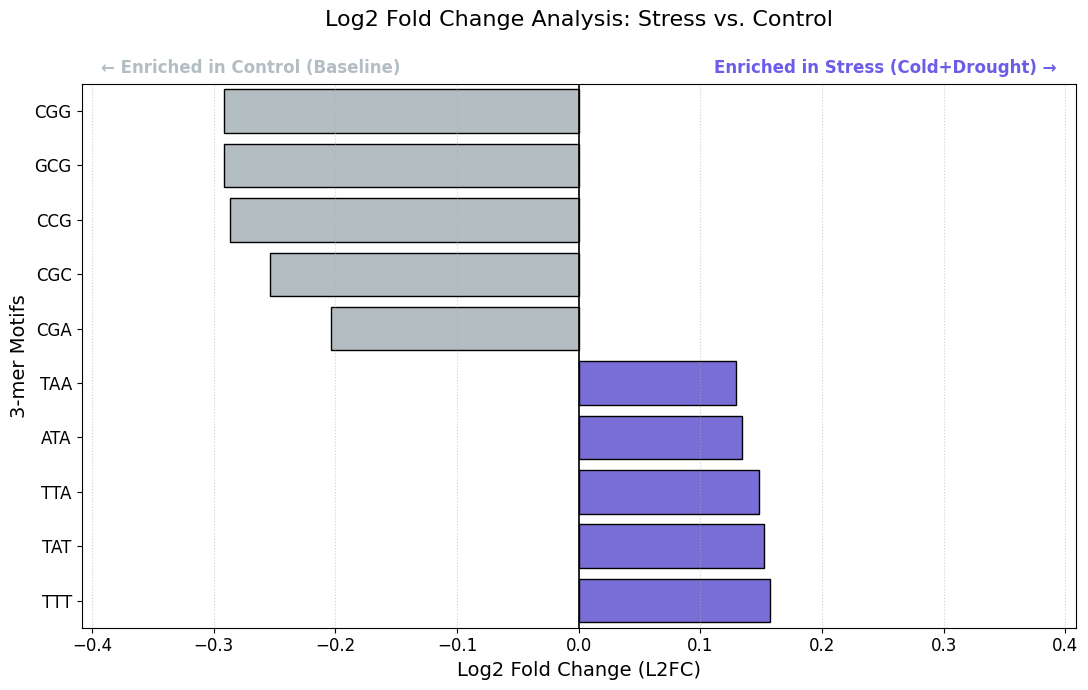

Success: Analysis complete. Plot saved as unified_stress_top_10_log2fc.tiff

Top 5 Stress-Enriched 3-mers (Log2FC):
TTT    0.156942
TAT    0.152112
TTA    0.148566
ATA    0.134468
TAA    0.129643
Name: Log2FC, dtype: float64

Top 5 Control-Enriched 3-mers (Log2FC):
CGG   -0.291910
GCG   -0.291304
CCG   -0.286522
CGC   -0.253372
CGA   -0.203299
Name: Log2FC, dtype: float64


In [11]:

# 1. 'diff_summary' contains the mean densities for 'Stress' and 'Control'
data_metrics = diff_summary.copy()

# 2. Calculate Log2 Fold Change (Log2FC)
# Adding a small constant (pseudocount) to prevent division by zero or log(0) errors
pseudocount = 1e-5
data_metrics['Log2FC'] = np.log2((data_metrics['Stress'] + pseudocount) / (data_metrics['Control'] + pseudocount))

# 3. SELECT TOP 5 ENRICHED AND TOP 5 DEPLETED MOTIFS
# 'ascending=False' for Stress-enriched (highest values)
enriched_top = data_metrics.sort_values(by='Log2FC', ascending=False).head(5)
# 'ascending=True' for Control-enriched (lowest/most negative values)
depleted_top = data_metrics.sort_values(by='Log2FC', ascending=True).head(5)

# Combine and sort for a clean, symmetrical visualization
top_plot = pd.concat([enriched_top, depleted_top]).sort_values(by='Log2FC')

# 4. Visualization: High-Quality Horizontal Bar Plot
plt.figure(figsize=(11, 7))

# Define the color palette:
colors = ['#b2bec3' if x < 0 else '#6c5ce7' for x in top_plot['Log2FC']]

# Create the bar plot using Seaborn
ax = sns.barplot(x='Log2FC', y=top_plot.index, data=top_plot, palette=colors, edgecolor='black')

# 5. Dynamic Axis and Styling
# Expand X-axis limits by 40% to avoid label overlap
x_limit = max(abs(top_plot['Log2FC'].min()), abs(top_plot['Log2FC'].max())) * 1.4
plt.xlim(-x_limit, x_limit)

# Scientific Titles and Labels (Matched to Density Analysis sizes)
plt.title('Log2 Fold Change Analysis: Stress vs. Control\n', 
          fontsize=16, pad=25)

plt.xlabel('Log2 Fold Change (L2FC)', fontsize=14)
plt.ylabel('3-mer Motifs', fontsize=14)

# Increase tick label size for better readability in the thesis
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Add a central vertical reference line at zero
plt.axvline(0, color='black', linewidth=1.2)

# Strategic Labels for quick interpretation (Fontsize 12)
plt.text(0.98, 1.02, 'Enriched in Stress (Cold+Drought) →', transform=ax.transAxes, 
         color='#6c5ce7', fontweight='bold', ha='right', fontsize=12)

plt.text(0.02, 1.02, '← Enriched in Control (Baseline)', transform=ax.transAxes, 
         color='#b2bec3', fontweight='bold', ha='left', fontsize=12)

# Fine-tune grid aesthetics
plt.grid(axis='x', linestyle=':', alpha=0.6)
plt.tight_layout()

# 6. High-Resolution Export
# Output as TIFF with 300 DPI and LZW compression
output_filename = 'unified_stress_top_10_log2fc.tiff'
plt.savefig(output_filename, dpi=300, format='tiff', 
            bbox_inches='tight', pil_kwargs={'compression': 'tiff_lzw'})

plt.show()

# 7. Print Summary Results to verify the Top 5
print(f"Success: Analysis complete. Plot saved as {output_filename}")
print("\nTop 5 Stress-Enriched 3-mers (Log2FC):")
print(enriched_top['Log2FC'])
print("\nTop 5 Control-Enriched 3-mers (Log2FC):")
print(depleted_top['Log2FC'])